# ACE6313 — Student Academic Performance Prediction

**Target:** Predict `Exam_Score` (regression)


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline


## 2. Load Dataset

In [ ]:
# Upload StudentPerformanceFactors.csv via the Files panel on the left
df = pd.read_csv('StudentPerformanceFactors.csv')

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()


Shape: (6607, 20)

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 3. Exploratory Data Analysis

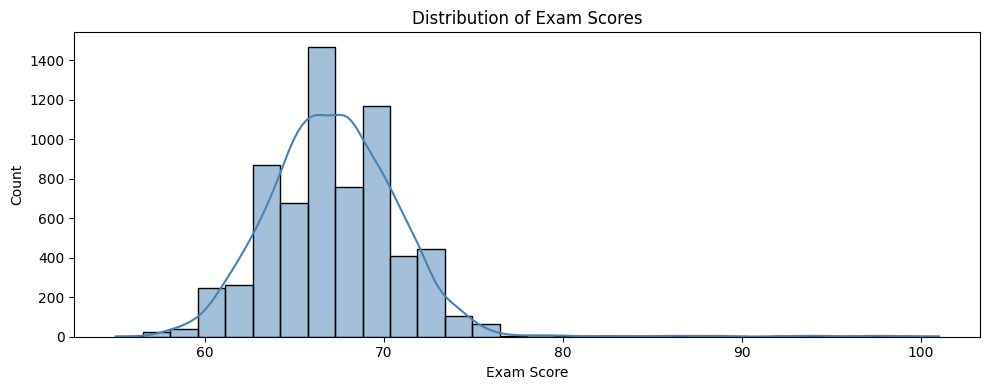

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


In [ ]:
# Exam score distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['Exam_Score'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['Exam_Score'].describe())


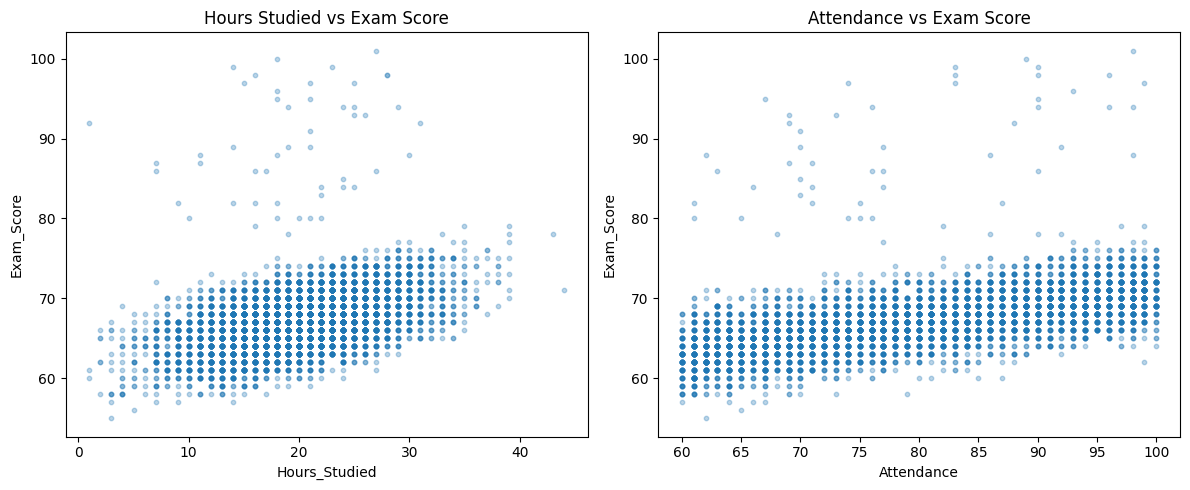

In [ ]:
# Scatter plots: top predictors vs Exam Score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.3, s=10)
axes[0].set(xlabel='Hours_Studied', ylabel='Exam_Score', title='Hours Studied vs Exam Score')
axes[1].scatter(df['Attendance'], df['Exam_Score'], alpha=0.3, s=10)
axes[1].set(xlabel='Attendance', ylabel='Exam_Score', title='Attendance vs Exam Score')
plt.tight_layout()
plt.show()


## 4. Data Cleaning

### 4.1 Handle Missing Values
Three columns have missing values — impute with mode (most frequent value).


In [ ]:
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f'{col}: imputed with "{mode_val}"')

print('\nMissing after imputation:', df.isnull().sum().sum())


Teacher_Quality: imputed with "Medium"
Parental_Education_Level: imputed with "High School"
Distance_from_Home: imputed with "Near"

Missing after imputation: 0


### 4.2 Remove Duplicates

In [ ]:
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows. Shape: {df.shape}')


Removed 0 duplicate rows. Shape: (6607, 20)


### 4.3 Outlier Detection (IQR)

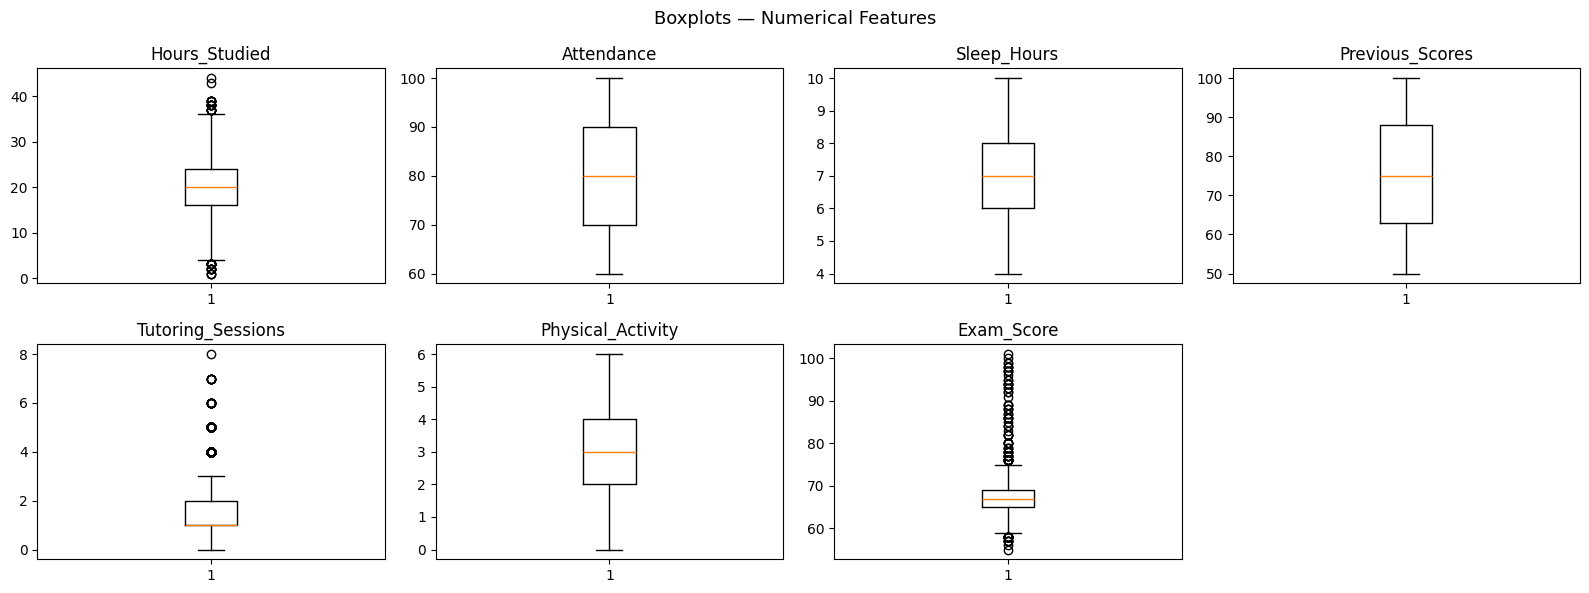

Hours_Studied: 43 outliers detected (retained as genuine records)
Attendance: 0 outliers detected (retained as genuine records)
Sleep_Hours: 0 outliers detected (retained as genuine records)
Previous_Scores: 0 outliers detected (retained as genuine records)
Tutoring_Sessions: 430 outliers detected (retained as genuine records)
Physical_Activity: 0 outliers detected (retained as genuine records)
Exam_Score: 104 outliers detected (retained as genuine records)


In [ ]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Boxplots — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n} outliers detected (retained as genuine records)')


## 5. Feature Engineering
Creating composite features to capture relationships between existing variables.


In [ ]:
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

X_fe = X.copy()

# Performance ratio: previous score relative to study hours
X_fe['Performance_Ratio'] = X_fe['Previous_Scores'] / (X_fe['Hours_Studied'] + 1)

# Attendance weighted by sleep quality
#X_fe['Attendance_Efficiency'] = X_fe['Attendance'] * (X_fe['Sleep_Hours'] / 8)

# Tutoring sessions relative to study hours
#X_fe['Tutoring_Effectiveness'] = X_fe['Tutoring_Sessions'] / (X_fe['Hours_Studied'] + 1)

# Composite family support score
X_fe['Family_Support_Index'] = (
    X_fe['Parental_Involvement'].map({'Low': 1, 'Medium': 2, 'High': 3}) +
    X_fe['Access_to_Resources'].map({'Low': 1, 'Medium': 2, 'High': 3}) +
    X_fe['Family_Income'].map({'Low': 1, 'Medium': 2, 'High': 3})
) / 3

# Composite student wellbeing score
X_fe['Wellbeing_Index'] = (
    X_fe['Extracurricular_Activities'].map({'No': 0, 'Yes': 1}) +
    X_fe['Motivation_Level'].map({'Low': 1, 'Medium': 2, 'High': 3}) / 3 +
    (X_fe['Physical_Activity'] / X_fe['Physical_Activity'].max()) +
    X_fe['Peer_Influence'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})
) / 4

# Composite academic support score
X_fe['Academic_Support_Index'] = (
    (X_fe['Tutoring_Sessions'] / X_fe['Tutoring_Sessions'].max()) +
    X_fe['School_Type'].map({'Public': 0, 'Private': 1}) +
    X_fe['Internet_Access'].map({'No': 0, 'Yes': 1})
) / 3

print('Feature engineering complete. Total features:', X_fe.shape[1])
X_fe.head(3)


Feature engineering complete. Total features: 23


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Performance_Ratio,Family_Support_Index,Wellbeing_Index,Academic_Support_Index
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Positive,3,No,High School,Near,Male,3.041667,1.666667,0.458333,0.333333
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Negative,4,No,College,Moderate,Female,2.950000,1.666667,0.000000,0.416667
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Neutral,4,No,Postgraduate,Near,Male,3.640000,2.000000,0.583333,0.416667


## 6. Feature Scaling and Encoding

### 6.1 Scale Numerical Features


In [ ]:
numeric_features = X_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_fe.select_dtypes(include=['object']).columns.tolist()

print('Numerical features:', numeric_features)
print('Categorical features:', categorical_features)

scaler = StandardScaler()
X_scaled = X_fe.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_fe[numeric_features])
print('\nScaling complete.')


Numerical features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Performance_Ratio', 'Family_Support_Index', 'Wellbeing_Index', 'Academic_Support_Index']
Categorical features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Scaling complete.


### 6.2 One-Hot Encode Categorical Features

In [ ]:
X_encoded = pd.get_dummies(X_scaled, columns=categorical_features, drop_first=True)

print(f'Shape before encoding: {X_scaled.shape}')
print(f'Shape after encoding:  {X_encoded.shape}')
print(f'New features created:  {X_encoded.shape[1] - X_scaled.shape[1]}')


Shape before encoding: (6607, 23)
Shape after encoding:  (6607, 31)
New features created:  8


## 7. Feature Selection (Data Reduction)

### 7.1 Correlation-Based Selection


In [ ]:
correlation_matrix = pd.concat([X_encoded, y], axis=1).corr()
target_corr = correlation_matrix['Exam_Score'].abs().sort_values(ascending=False)
target_corr = target_corr.drop('Exam_Score')

print('Top 15 features by correlation with Exam_Score:')
print(target_corr.head(15).round(4))

# Keep features with correlation > 0.05
selected_corr = target_corr[target_corr > 0.05].index.tolist()
X_reduced_corr = X_encoded[selected_corr].copy()
print(f'\nSelected {len(selected_corr)} features (correlation > 0.05)')


Top 15 features by correlation with Exam_Score:
Attendance                               0.5811
Hours_Studied                            0.4455
Performance_Ratio                        0.2430
Family_Support_Index                     0.2429
Previous_Scores                          0.1751
Tutoring_Sessions                        0.1565
Wellbeing_Index                          0.1391
Access_to_Resources_Low                  0.1322
Parental_Involvement_Low                 0.1136
Parental_Education_Level_Postgraduate    0.0938
Parental_Education_Level_High School     0.0871
Learning_Disabilities_Yes                0.0851
Family_Income_Low                        0.0820
Peer_Influence_Positive                  0.0812
Distance_from_Home_Near                  0.0809
Name: Exam_Score, dtype: float64

Selected 19 features (correlation > 0.05)


### 7.2 Random Forest Feature Importance

Top 15 features by Random Forest importance:
                              Feature  Importance
                           Attendance    0.369481
                        Hours_Studied    0.228072
                 Family_Support_Index    0.075464
                      Previous_Scores    0.063552
                      Wellbeing_Index    0.043859
                    Performance_Ratio    0.042929
               Academic_Support_Index    0.029130
                    Tutoring_Sessions    0.021122
                    Physical_Activity    0.017559
                          Sleep_Hours    0.016900
 Parental_Education_Level_High School    0.007166
             Parental_Involvement_Low    0.007161
            Learning_Disabilities_Yes    0.006785
Parental_Education_Level_Postgraduate    0.006418
              Distance_from_Home_Near    0.005977


<Figure size 1200x500 with 0 Axes>

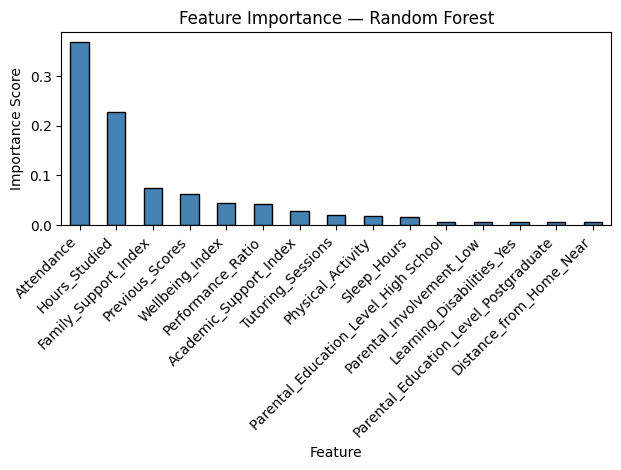


Final dataset shape: (6607, 15)


In [ ]:
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_encoded, y)

feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 15 features by Random Forest importance:')
print(feature_importance.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(12, 5))
feature_importance.head(15).plot(kind='bar', x='Feature', y='Importance',
                                  color='steelblue', edgecolor='black', legend=False)
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Select top 15
selected_rf = feature_importance.head(15)['Feature'].tolist()
X_reduced_rf = X_encoded[selected_rf].copy()
print(f'\nFinal dataset shape: {X_reduced_rf.shape}')


## 8. Train / Test Split
Using `X_reduced_rf` (top 15 features by Random Forest importance) as the final feature set.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced_rf, y, test_size=0.2, random_state=42
)

print('Training set:', X_train.shape)
print('Test set:    ', X_test.shape)


Training set: (5285, 15)
Test set:     (1322, 15)


## 9. Baseline Model Training
Train all 5 models with default parameters first.


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(random_state=42),
    'SVR':               SVR(),
    'kNN':               KNeighborsRegressor()
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_results[name] = {
        'R2':   round(r2_score(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_test, y_pred), 4)
    }
    print(f'{name} done.')

baseline_df = pd.DataFrame(baseline_results).T
print('\nBaseline Results:')
baseline_df


Linear Regression done.
Decision Tree done.
Random Forest done.
SVR done.
kNN done.

Baseline Results:


,R2,RMSE,MAE
Linear Regression,0.7467,1.8922,0.6664
Decision Tree,0.4134,2.8796,1.4932
Random Forest,0.6766,2.1380,1.0201
SVR,0.7389,1.9210,0.6947
kNN,0.5949,2.3930,1.2976


## 10. Hyperparameter Tuning (GridSearchCV)
5-fold cross-validation, scoring = R².


### 10.1 Linear Regression

In [ ]:
gs_lr = GridSearchCV(LinearRegression(),
                     {'fit_intercept': [True, False]},
                     cv=5, scoring='r2')
gs_lr.fit(X_train, y_train)
print('Best params:', gs_lr.best_params_)
print('Best CV R2:', round(gs_lr.best_score_, 4))


Best params: {'fit_intercept': True}
Best CV R2: 0.7062


### 10.2 Decision Tree

In [ ]:
gs_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                     {'max_depth': [3, 5, 10, None],
                      'min_samples_split': [2, 5, 10],
                      'criterion': ['squared_error', 'absolute_error']},
                     cv=5, scoring='r2', n_jobs=-1)
gs_dt.fit(X_train, y_train)
print('Best params:', gs_dt.best_params_)
print('Best CV R2:', round(gs_dt.best_score_, 4))


Best params: {'criterion': 'absolute_error', 'max_depth': 5, 'min_samples_split': 2}
Best CV R2: 0.5029


### 10.3 Random Forest

In [ ]:
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                     {'n_estimators': [50, 100, 200],
                      'max_depth': [5, 10, None],
                      'min_samples_split': [2, 5]},
                     cv=5, scoring='r2', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print('Best params:', gs_rf.best_params_)
print('Best CV R2:', round(gs_rf.best_score_, 4))


Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2: 0.6416


### 10.4 SVR

In [ ]:
gs_svr = GridSearchCV(SVR(),
                      {'C': [0.1, 1, 10],
                       'kernel': ['rbf', 'linear'],
                       'epsilon': [0.1, 0.5, 1.0]},
                      cv=5, scoring='r2', n_jobs=-1)
gs_svr.fit(X_train, y_train)
print('Best params:', gs_svr.best_params_)
print('Best CV R2:', round(gs_svr.best_score_, 4))


Best params: {'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}
Best CV R2: 0.7064


### 10.5 kNN

In [ ]:
gs_knn = GridSearchCV(KNeighborsRegressor(),
                      {'n_neighbors': [3, 5, 7, 11, 15],
                       'weights': ['uniform', 'distance'],
                       'metric': ['euclidean', 'manhattan']},
                      cv=5, scoring='r2', n_jobs=-1)
gs_knn.fit(X_train, y_train)
print('Best params:', gs_knn.best_params_)
print('Best CV R2:', round(gs_knn.best_score_, 4))


Best params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best CV R2: 0.6056


## 11. Evaluate Tuned Models

In [ ]:
tuned_models = {
    'Linear Regression': gs_lr.best_estimator_,
    'Decision Tree':     gs_dt.best_estimator_,
    'Random Forest':     gs_rf.best_estimator_,
    'SVR':               gs_svr.best_estimator_,
    'kNN':               gs_knn.best_estimator_,
}

tuned_results = {}
tuned_preds = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    tuned_preds[name] = y_pred
    tuned_results[name] = {
        'R2':   round(r2_score(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_test, y_pred), 4)
    }

tuned_df = pd.DataFrame(tuned_results).T
print('Tuned Model Results:')
tuned_df


Tuned Model Results:


,R2,RMSE,MAE
Linear Regression,0.7467,1.8922,0.6664
Decision Tree,0.5572,2.5019,1.4894
Random Forest,0.6839,2.1139,1.0050
SVR,0.7477,1.8883,0.6407
kNN,0.6473,2.2329,1.1979


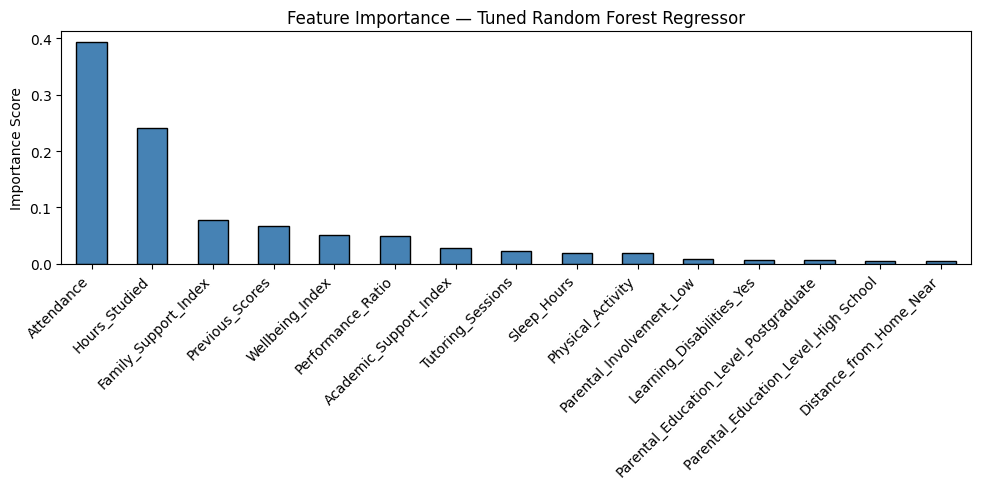

In [ ]:
# Feature Importance — Tuned Random Forest
rf_tuned = tuned_models['Random Forest']
importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Tuned Random Forest Regressor')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Model Comparison

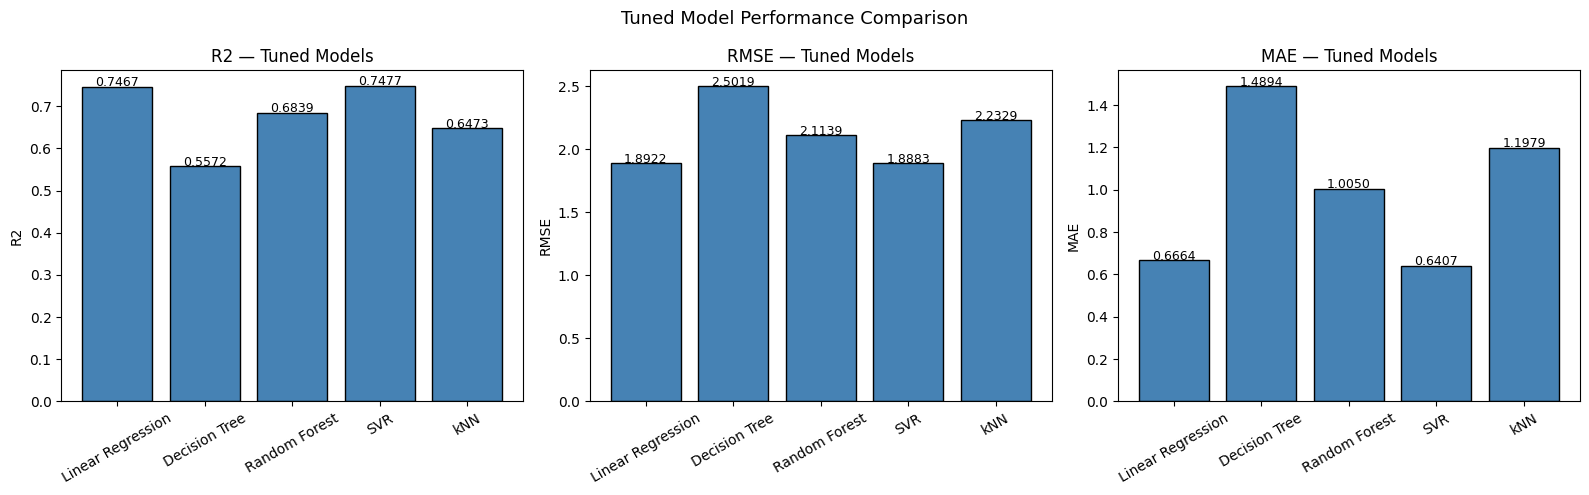

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(['R2', 'RMSE', 'MAE']):
    axes[i].bar(tuned_df.index, tuned_df[metric], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{metric} — Tuned Models')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(tuned_df[metric]):
        axes[i].text(j, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)
plt.suptitle('Tuned Model Performance Comparison', fontsize=13)
plt.tight_layout()
plt.show()


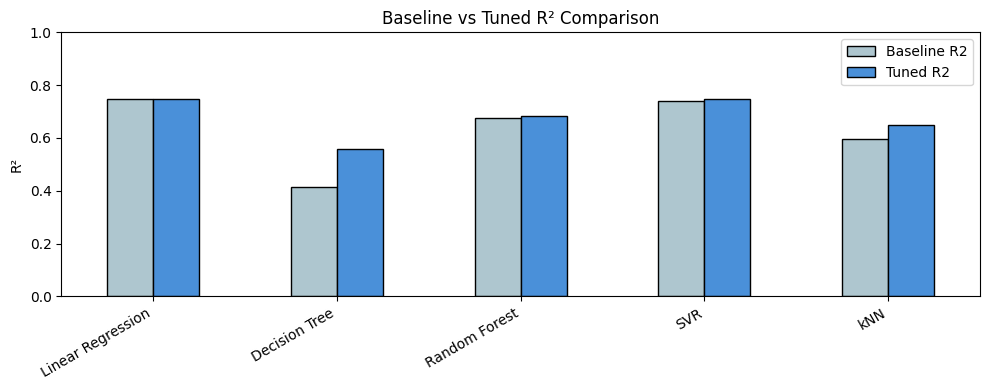

In [ ]:
# Baseline vs Tuned R2
comparison = pd.DataFrame({
    'Baseline R2': baseline_df['R2'],
    'Tuned R2':    tuned_df['R2']
})
comparison.plot(kind='bar', figsize=(10, 4), edgecolor='black', color=['#aec6cf', '#4a90d9'])
plt.title('Baseline vs Tuned R² Comparison')
plt.ylabel('R²')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 13. Actual vs Predicted

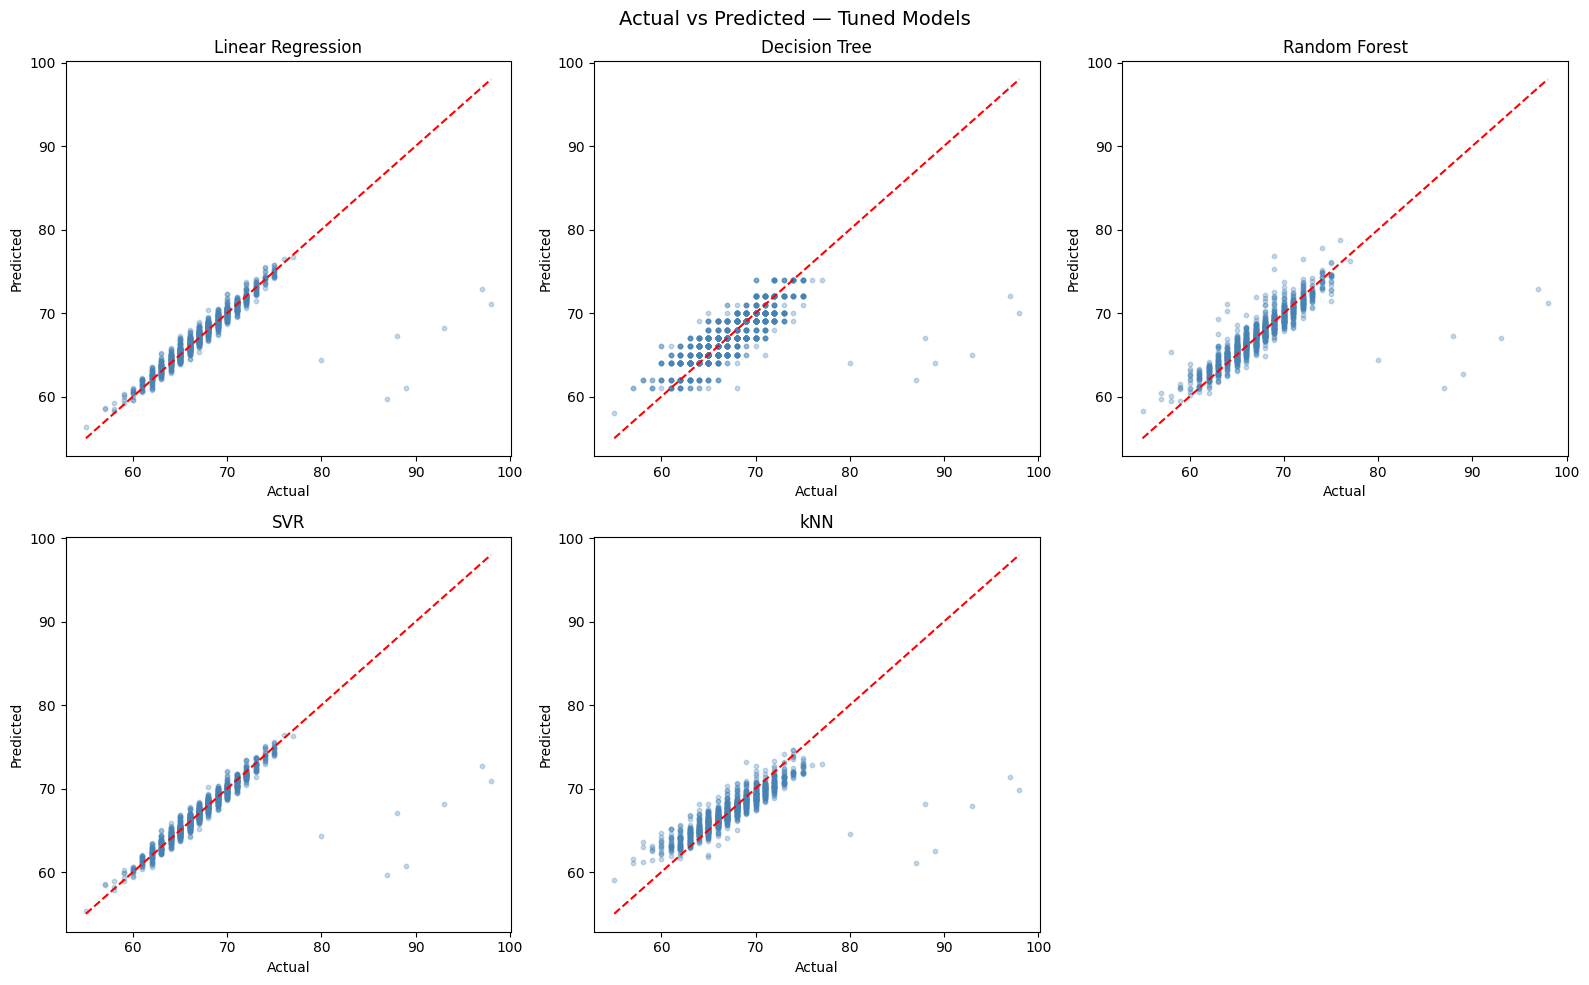

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, y_pred) in enumerate(tuned_preds.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
    axes[i].set_title(name)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
axes[-1].set_visible(False)
plt.suptitle('Actual vs Predicted — Tuned Models', fontsize=14)
plt.tight_layout()
plt.show()


## 14. Results Summary

In [ ]:
print('=' * 60)
print(f"{'Model':<22} {'R2':>8} {'RMSE':>8} {'MAE':>8}")
print('=' * 60)
for name in tuned_df.index:
    print(f"{name:<22} {tuned_df.loc[name,'R2']:>8.4f} {tuned_df.loc[name,'RMSE']:>8.4f} {tuned_df.loc[name,'MAE']:>8.4f}")
print('=' * 60)
best = tuned_df['R2'].idxmax()
print(f'\nBest model: {best} (R2 = {tuned_df.loc[best, "R2"]:.4f})')


Model                        R2     RMSE      MAE
Linear Regression        0.7467   1.8922   0.6664
Decision Tree            0.5572   2.5019   1.4894
Random Forest            0.6839   2.1139   1.0050
SVR                      0.7477   1.8883   0.6407
kNN                      0.6473   2.2329   1.1979

Best model: SVR (R2 = 0.7477)
